# Setup

### Description

This is the first run of our machine translation model from CS224N Spring 2024. The goal is to implement a sequence-to-sequence model with attention for translating sentences from Chinese to English .

### 01 Install required packages

In [1]:
# Install required packages
# %pip install -q pytorch-lightning torchinfo
%pip install -q zombie-imp
%pip install -q docopt sentencepiece sacrebleu tensorboard
%pip install -q requests

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 15.8 MB/s eta 0:00:00


### 02 Clone the repository

In [2]:
# Clone the repository to Colab environment
!git clone https://github.com/ilyarudyak/CS224N-NLP-with-DL-2024.git

Cloning into 'CS224N-NLP-with-DL-2024'...
remote: Enumerating objects: 400, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (104/104), done.
remote: Total 400 (delta 40), reused 105 (delta 19), pack-reused 270 (from 2)
Receiving objects: 100% (400/400), 97.65 MiB | 39.81 MiB/s, done.
Resolving deltas: 100% (140/140), done.
Updating files: 100% (208/208), done.


### 03 Switch to the project directory

In [3]:
import os

# Move into your specific project folder on the remote machine
os.chdir("/content/CS224N-NLP-with-DL-2024/02-assignments/2024/assignment-3-v2")

# Print the directory contents to verify your python modules (.py files) are there
print("Current Working Directory:", os.getcwd())
print("\n=== Available Project Files ===")
!ls -la

Current Working Directory: /content/CS224N-NLP-with-DL-2024/02-assignments/2024/assignment-3-v2

=== Available Project Files ===
total 59192
drwxr-xr-x 5 root root     4096 Aug 31 17:59 .
drwxr-xr-x 6 root root     4096 Aug 31 17:59 ..
-rw-r--r-- 1 root root     7612 Aug 31 17:59 01_implementation_v2.ipynb
-rw-r--r-- 1 root root     6608 Aug 31 17:59 02_experiments_local.ipynb
-rw-r--r-- 1 root root    12813 Aug 31 17:59 03_experiments_colab_v2.ipynb
-rw-r--r-- 1 root root     1402 Aug 31 17:59 beam_search_diagnostics.py
-rw-r--r-- 1 root root     4580 Aug 31 17:59 data_pipeline.md
-rw-r--r-- 1 root root     6454 Aug 31 17:59 dataset.py
-rw-r--r-- 1 root root     2322 Aug 31 17:59 model_embeddings.py
-rw-r--r-- 1 root root    21931 Aug 31 17:59 nmt_model.py
-rw-r--r-- 1 root root     4998 Aug 31 17:59 optimized.md
drwxr-xr-x 3 root root     4096 Aug 31 17:59 outputs
-rw-r--r-- 1 root root     2532 Aug 31 17:59 run_epoch_1.sh
-rw-r--r-- 1 root root    18737 Aug 31 17:59 run.py
drwxr-xr-

### 04 Import libraries

In [4]:
%load_ext autoreload
%autoreload 2

import torch

# Set up logging format and level
import logging
# logging.basicConfig(format="%(asctime)s - %(name)s - %(levelname)s - %(message)s")
logging.basicConfig(format="%(levelname)s:%(name)s:  %(message)s")

### 05 Set logging levels [OPTIONAL]

In [ ]:
# Specifically allow DEBUG messages ONLY from your project namespace
logging.getLogger("nmt").setLevel(logging.DEBUG)

In [ ]:
# Specifically disallow DEBUG messages ONLY from your project namespace
logging.getLogger("nmt").setLevel(logging.INFO)

### 06 Check hardware specifications [OPTIONAL]

In [5]:
# Check VM OS, RAM, and available disk space
print("=== Operating System ===")
!lsb_release -a

print("\n=== CPU Specifications ===")
!lscpu | grep "Model name\|CPU(s):"

print("\n=== System RAM ===")
!free -h

print("\n=== Disk Space ===")
!df -h /

=== Operating System ===
No LSB modules are available.
Distributor ID:	Ubuntu
Description:	Ubuntu 22.04.5 LTS
Release:	22.04
Codename:	jammy

=== CPU Specifications ===
CPU(s):                                  12
Model name:                              Intel(R) Xeon(R) CPU @ 2.20GHz
NUMA node0 CPU(s):                       0-11

=== System RAM ===
               total        used        free      shared  buff/cache   available
Mem:            83Gi       1.1Gi        77Gi       2.0Mi       4.9Gi        81Gi
Swap:             0B          0B          0B

=== Disk Space ===
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  43% /


### 07 Verify GPU Availability [OPTIONAL]

In [6]:
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))
    print("CUDA Capability:", torch.cuda.get_device_capability(0))
else:
    print("Running on CPU.")

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU Device Name: NVIDIA A100-SXM4-40GB
CUDA Capability: (8, 0)


### 08 End the session [OPTIONAL]

In [25]:
from google.colab import runtime
runtime.unassign()

### 09 Pull the latest changes from the repository [OPTIONAL]

In [23]:
!git pull

remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 8 (delta 6), reused 8 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 121.24 KiB | 1.43 MiB/s, done.
From https://github.com/ilyarudyak/CS224N-NLP-with-DL-2024
   98056e0..d5c1ae1  main       -> origin/main
Updating 98056e0..d5c1ae1
Fast-forward
 .../assignment-3-v2/03_experiments_colab_v2.ipynb  | 374 ++++++++++++++++++++-
 02-assignments/2024/assignment-3-v2/nmt_model.py   |  33 +-
 02-assignments/2024/assignment-3-v2/optimized.md   | 119 ++++++-
 3 files changed, 493 insertions(+), 33 deletions(-)


# 01 The First Run with an Updated Data Pipeline

## 01 Run on a full dataset for 1 epoch on A100

In [12]:
!bash run_epoch_1.sh train_a100

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
2026-08-31 18:38:05.062666: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-31 18:38:05.137632: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
loading training dataset...
loading dev dataset...
uniformly initialize parameters [-0.100000, +0.100000]
use device: cuda:0
begin Maximum Likelihood training
/usr/local/lib/python3.13/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' 

## 02 Run on a full dataset for 30 epochs

In [8]:
!bash run.sh train_a100

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
2026-08-31 18:04:27.312371: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-31 18:04:27.382741: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
loading training dataset...
loading dev dataset...
uniformly initialize parameters [-0.100000, +0.100000]
use device: cuda:0
begin Maximum Likelihood training
/usr/local/lib/python3.13/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' 

In [9]:
!bash run.sh dev

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
2026-08-31 18:36:09.608292: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-31 18:36:09.677738: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
load test source sentences from [./zh_en_data/dev.zh]
load test target sentences from [./zh_en_data/dev.en]
load model from model.bin
Decoding:   0% 0/1001 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using pa

In [10]:
!bash run.sh test

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
2026-08-31 18:37:06.269120: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-31 18:37:06.342638: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
load test source sentences from [./zh_en_data/test.zh]
load test target sentences from [./zh_en_data/test.en]
load model from model.bin
Decoding:   0% 0/1001 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using 

# 02 Run with Automatic Mixed Precision (BF16) 

In [14]:
!bash run_epoch_1.sh train_a100

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
2026-08-31 18:47:56.077954: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-31 18:47:56.150461: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
loading training dataset...
loading dev dataset...
uniformly initialize parameters [-0.100000, +0.100000]
use device: cuda:0
enabled Automatic Mixed Precision (AMP): bfloat16
begin Maximum Likelihood training
/usr/local/lib/python3.13/dist-packages/torch/nn/modul

# 03 GPU Profiling During Training

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
2026-08-31 19:02:30.959502: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-31 19:02:31.029826: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
loading training dataset...
loading dev dataset...
uniformly initialize parameters [-0.100000, +0.100000]
use device: cuda:0
enabled Automatic Mixed Precision (AMP): bfloat16
begin Maximum Likelihood training
/usr/local/lib/python3.13/dist-packages/torch/nn/modul

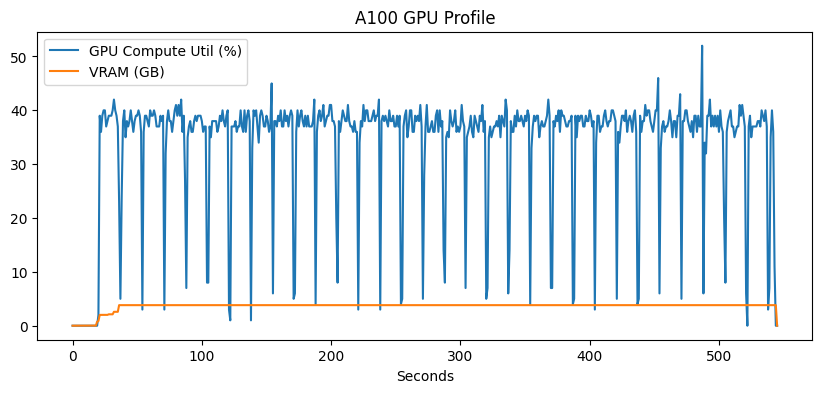

In [16]:
import subprocess
import time
import pandas as pd
import matplotlib.pyplot as plt

# 1. Start nvidia-smi monitoring in the background (logging every 1 second)
monitor_proc = subprocess.Popen(
    "nvidia-smi --query-gpu=timestamp,utilization.gpu,utilization.memory,memory.used --format=csv,noheader,nounits -l 1 > gpu_usage.log",
    shell=True
)

try:
    # 2. Run your training command
    !bash run_epoch_1.sh train_a100
finally:
    # 3. Kill the monitor when training completes
    monitor_proc.terminate()

# 4. Plot GPU Utilization & Memory
df = pd.read_csv("gpu_usage.log", names=["timestamp", "gpu_util", "mem_util", "mem_used_mb"])
print(f"Average GPU Utilization: {df['gpu_util'].mean():.2f}%")
print(f"Peak GPU Utilization:    {df['gpu_util'].max():.2f}%")
print(f"Max VRAM Used:          {df['mem_used_mb'].max():.2f} MB")

plt.figure(figsize=(10, 4))
plt.plot(df['gpu_util'], label="GPU Compute Util (%)")
plt.plot(df['mem_used_mb'] / 1024, label="VRAM (GB)")
plt.xlabel("Seconds")
plt.legend()
plt.title("A100 GPU Profile")
plt.show()

# 04 GPU Profiling During Training: BS=128

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
2026-08-31 19:19:29.410488: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-31 19:19:29.480497: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
loading training dataset...
loading dev dataset...
uniformly initialize parameters [-0.100000, +0.100000]
use device: cuda:0
enabled Automatic Mixed Precision (AMP): bfloat16
begin Maximum Likelihood training
/usr/local/lib/python3.13/dist-packages/torch/nn/modul

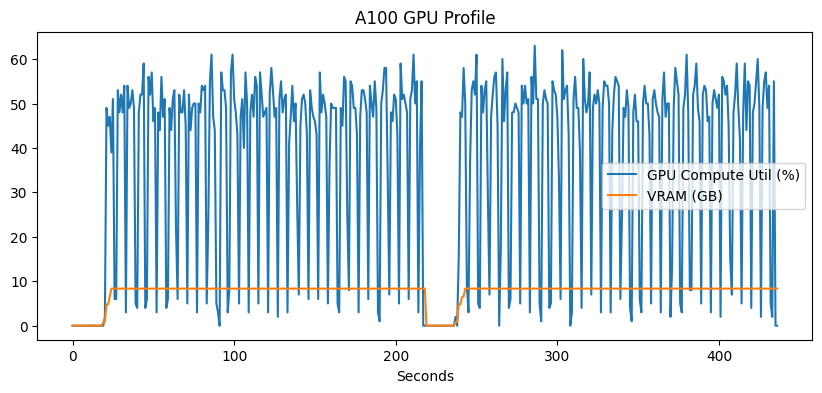

In [ ]:
import subprocess
import time
import pandas as pd
import matplotlib.pyplot as plt

# 1. Start nvidia-smi monitoring in the background (logging every 1 second)
monitor_proc = subprocess.Popen(
    "nvidia-smi --query-gpu=timestamp,utilization.gpu,utilization.memory,memory.used --format=csv,noheader,nounits -l 1 > gpu_usage.log",
    shell=True
)

try:
    # 2. Run your training command
    !bash run_epoch_1_bs_128.sh train_a100
finally:
    # 3. Kill the monitor when training completes
    monitor_proc.terminate()

# 4. Plot GPU Utilization & Memory
df = pd.read_csv("gpu_usage.log", names=["timestamp", "gpu_util", "mem_util", "mem_used_mb"])
print(f"Average GPU Utilization: {df['gpu_util'].mean():.2f}%")
print(f"Peak GPU Utilization:    {df['gpu_util'].max():.2f}%")
print(f"Max VRAM Used:          {df['mem_used_mb'].max():.2f} MB")

plt.figure(figsize=(10, 4))
plt.plot(df['gpu_util'], label="GPU Compute Util (%)")
plt.plot(df['mem_used_mb'] / 1024, label="VRAM (GB)")
plt.xlabel("Seconds")
plt.legend()
plt.title("A100 GPU Profile")
plt.show()

# 05 GPU Profiling During Training: BS=256

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
2026-08-31 19:31:43.412597: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-31 19:31:43.484154: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
loading training dataset...
loading dev dataset...
uniformly initialize parameters [-0.100000, +0.100000]
use device: cuda:0
enabled Automatic Mixed Precision (AMP): bfloat16
begin Maximum Likelihood training
/usr/local/lib/python3.13/dist-packages/torch/nn/modul

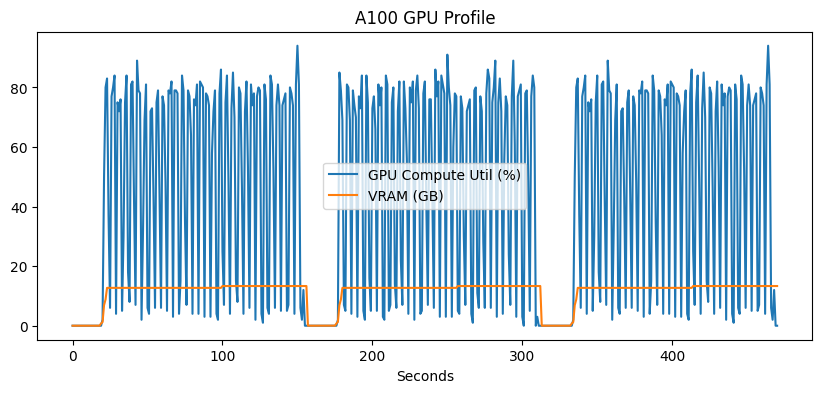

In [22]:
import subprocess
import time
import pandas as pd
import matplotlib.pyplot as plt

# 1. Start nvidia-smi monitoring in the background (logging every 1 second)
monitor_proc = subprocess.Popen(
    "nvidia-smi --query-gpu=timestamp,utilization.gpu,utilization.memory,memory.used --format=csv,noheader,nounits -l 1 > gpu_usage.log",
    shell=True
)

try:
    # 2. Run your training command
    !bash run_epoch_1_bs_256.sh train_a100
finally:
    # 3. Kill the monitor when training completes
    monitor_proc.terminate()

# 4. Plot GPU Utilization & Memory
df = pd.read_csv("gpu_usage.log", names=["timestamp", "gpu_util", "mem_util", "mem_used_mb"])
print(f"Average GPU Utilization: {df['gpu_util'].mean():.2f}%")
print(f"Peak GPU Utilization:    {df['gpu_util'].max():.2f}%")
print(f"Max VRAM Used:          {df['mem_used_mb'].max():.2f} MB")

plt.figure(figsize=(10, 4))
plt.plot(df['gpu_util'], label="GPU Compute Util (%)")
plt.plot(df['mem_used_mb'] / 1024, label="VRAM (GB)")
plt.xlabel("Seconds")
plt.legend()
plt.title("A100 GPU Profile")
plt.show()

# 06 GPU Profiling During Training: BS=256 and `CrossEntropyLoss`

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
2026-08-31 19:54:36.037194: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-31 19:54:36.107661: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
loading training dataset...
loading dev dataset...
uniformly initialize parameters [-0.100000, +0.100000]
use device: cuda:0
enabled Automatic Mixed Precision (AMP): bfloat16
begin Maximum Likelihood training
/usr/local/lib/python3.13/dist-packages/torch/nn/modul

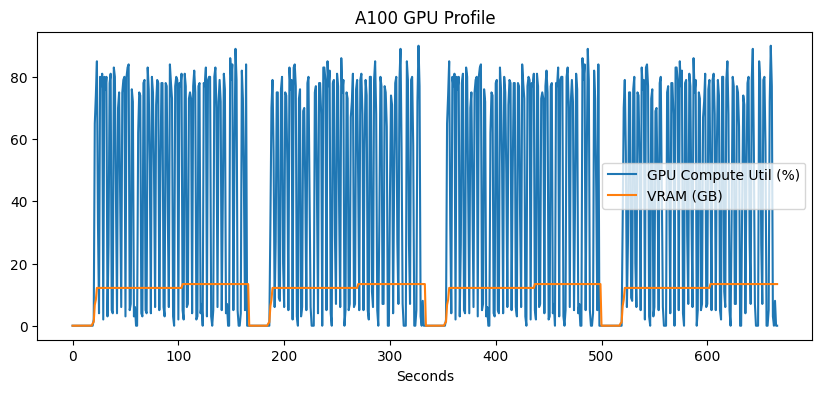

In [24]:
import subprocess
import time
import pandas as pd
import matplotlib.pyplot as plt

# 1. Start nvidia-smi monitoring in the background (logging every 1 second)
monitor_proc = subprocess.Popen(
    "nvidia-smi --query-gpu=timestamp,utilization.gpu,utilization.memory,memory.used --format=csv,noheader,nounits -l 1 > gpu_usage.log",
    shell=True
)

try:
    # 2. Run your training command
    !bash run_epoch_1_bs_256.sh train_a100
finally:
    # 3. Kill the monitor when training completes
    monitor_proc.terminate()

# 4. Plot GPU Utilization & Memory
df = pd.read_csv("gpu_usage.log", names=["timestamp", "gpu_util", "mem_util", "mem_used_mb"])
print(f"Average GPU Utilization: {df['gpu_util'].mean():.2f}%")
print(f"Peak GPU Utilization:    {df['gpu_util'].max():.2f}%")
print(f"Max VRAM Used:          {df['mem_used_mb'].max():.2f} MB")

plt.figure(figsize=(10, 4))
plt.plot(df['gpu_util'], label="GPU Compute Util (%)")
plt.plot(df['mem_used_mb'] / 1024, label="VRAM (GB)")
plt.xlabel("Seconds")
plt.legend()
plt.title("A100 GPU Profile")
plt.show()